In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [3]:
#keep today's notebook relatively self-contained.
first_purchase = (
    df.groupby("customer_id")["order_date"]
      .min()
      .reset_index()
)

first_purchase = first_purchase.rename(
    columns={
        "order_date": "first_purchase_date"
    }
)

In [4]:
first_purchase["cohort_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
)

In [5]:
df = df.merge(
    first_purchase[
        ["customer_id", "cohort_month"]
    ],
    on="customer_id",
    how="left"
)

In [6]:
# order month
df["order_month"] = (
    df["order_date"]
    .dt.to_period("M")
)

In [7]:
# cohort index:
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    +
    (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

In [8]:
# Building customer retention data
customer_month = (
    df[
        [
            "customer_id",
            "cohort_month",
            "order_month",
            "cohort_index"
        ]
    ]
    .drop_duplicates()
)

In [9]:
# the retention matrix
cohort_customers = (
    customer_month
    .groupby(
        ["cohort_month", "cohort_index"]
    )["customer_id"]
    .nunique()
    .reset_index()
)

In [10]:
retention_counts = cohort_customers.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

In [11]:
# %
retention_pct = (
    retention_counts
    .div(retention_counts.iloc[:, 0], axis=0)
    * 100
)

retention_pct = retention_pct.round(2)

retention_pct

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2025-01,100.0,44.34,44.34,45.75,48.58,45.75,41.51,44.34,41.98,46.70,42.45,40.57,41.98,41.04,43.87,44.34,41.04,42.45
2025-02,100.0,44.14,40.54,27.03,39.64,45.95,40.54,44.14,49.55,36.94,43.24,39.64,37.84,50.45,46.85,45.95,37.84,NaN
2025-03,100.0,41.03,41.03,46.15,51.28,38.46,48.72,37.18,37.18,56.41,44.87,43.59,47.44,34.62,46.15,44.87,NaN,NaN
2025-04,100.0,45.45,38.64,43.18,47.73,38.64,43.18,38.64,50.00,47.73,38.64,38.64,31.82,47.73,54.55,NaN,NaN,NaN
2025-05,100.0,46.15,38.46,38.46,42.31,38.46,46.15,46.15,46.15,42.31,30.77,23.08,46.15,26.92,NaN,NaN,NaN,NaN
2025-06,100.0,25.00,87.50,37.50,62.50,50.00,37.50,75.00,37.50,50.00,62.50,75.00,37.50,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,71.43,28.57,28.57,NaN,57.14,71.43,42.86,42.86,57.14,71.43,71.43,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,NaN,40.00,40.00,80.00,80.00,40.00,NaN,60.00,40.00,20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,80.00,60.00,20.00,40.00,40.00,20.00,20.00,20.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# the overall retention curve
average_retention = (
    retention_pct
    .mean(axis=0)
    .round(2)
)

In [13]:
average_retention

cohort_index
0     100.00
1      66.46
2      51.91
3      47.88
4      56.89
5      48.27
6      48.90
7      49.81
8      42.80
9      48.58
10     44.24
11     47.42
12     40.46
13     40.15
14     47.86
15     45.05
16     39.44
17     42.45
dtype: float64

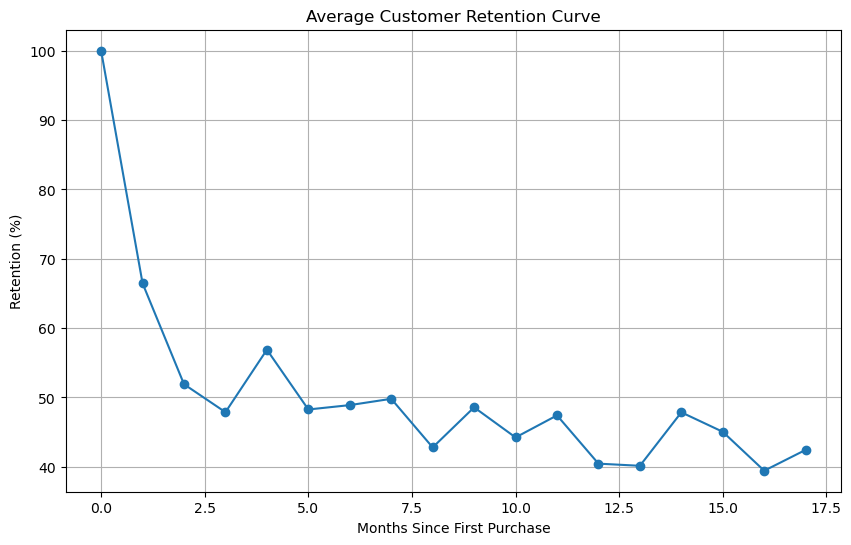

In [14]:
# the retention curve
plt.figure(figsize=(10, 6))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention (%)")

plt.grid()

plt.show()

In [15]:
# Calculate retention drop
month_1 = average_retention.get(1, np.nan)
month_3 = average_retention.get(3, np.nan)

In [16]:
retention_drop = month_1 - month_3

print(
    "Month 1 Retention:",
    month_1,
    "%"
)

print(
    "Month 3 Retention:",
    month_3,
    "%"
)

print(
    "Retention Drop:",
    round(retention_drop, 2),
    "percentage points"
)

Month 1 Retention: 66.46 %
Month 3 Retention: 47.88 %
Retention Drop: 18.58 percentage points


In [17]:
# repeat purchase rate
orders_per_customer = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

In [18]:
repeat_customers = (
    orders_per_customer > 1
).sum()

In [19]:
total_customers = (
    orders_per_customer.shape[0]
)

In [20]:
repeat_purchase_rate = (
    repeat_customers
    / total_customers
    * 100
)

In [21]:
print(
    "Repeat Purchase Rate:",
    round(repeat_purchase_rate, 2),
    "%"
)

Repeat Purchase Rate: 100.0 %


In [22]:
# Customer Lifetime Value Proxy
customer_value = (
    df.groupby("customer_id")
      .agg(
          Total_Revenue=("net_sales", "sum"),
          Total_Orders=("order_id", "nunique"),
          First_Purchase=("order_date", "min"),
          Last_Purchase=("order_date", "max")
      )
)

In [23]:
# customer lifespan
customer_value["Customer_Lifespan_Days"] = (
    customer_value["Last_Purchase"]
    - customer_value["First_Purchase"]
).dt.days

In [24]:
customer_value.head()

,Total_Revenue,Total_Orders,First_Purchase,Last_Purchase,Customer_Lifespan_Days
customer_id,,,,,
C0001,135820.0,7,2025-01-16 16:46:45.681136227,2026-05-16 15:04:30.054010800,484
C0002,300600.0,9,2025-02-15 11:05:24.784956991,2026-06-17 16:19:58.319663928,487
C0003,878500.0,13,2025-01-01 15:41:56.903380676,2026-06-12 21:12:21.028205640,527
C0004,1108185.0,16,2025-02-05 23:27:09.685937187,2026-05-05 09:34:23.212642528,453
C0005,100500.0,4,2025-05-30 21:43:10.358071614,2026-06-04 19:34:59.219843968,369


In [25]:
# revenue-per-order metric
customer_value["Revenue_Per_Order"] = (
    customer_value["Total_Revenue"]
    / customer_value["Total_Orders"]
)

In [26]:
# one-time vs repeat customers
customer_value["Customer_Type"] = np.where(
    customer_value["Total_Orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

In [27]:
customer_type_summary = (
    customer_value
    .groupby("Customer_Type")
    .agg(
        Customers=("Total_Revenue", "count"),
        Total_Revenue=("Total_Revenue", "sum"),
        Average_Revenue=("Total_Revenue", "mean"),
        Average_Orders=("Total_Orders", "mean")
    )
)

In [28]:
customer_type_summary

,Customers,Total_Revenue,Average_Revenue,Average_Orders
Customer_Type,,,,
Repeat Customer,500,279094300.0,558188.6,10.0


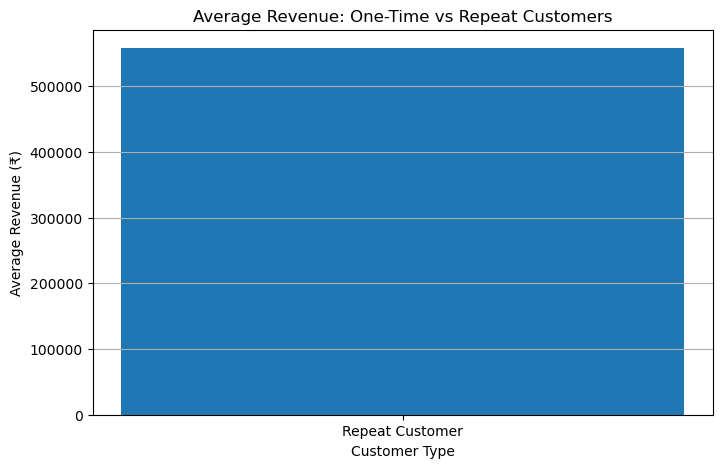

In [29]:
# Compare customer types
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_summary.index,
    customer_type_summary["Average_Revenue"]
)

plt.title("Average Revenue: One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Average Revenue (₹)")

plt.grid(axis="y")

plt.show()

# Day 13 — Customer Retention Deep-Dive Insights

## Overall Retention

DataPulse recorded an average Month 1 retention rate of **66.46%**
and an average Month 3 retention rate of **47.88%**.

This represents a decline of **18.58 percentage points**
between Month 1 and Month 3.

The retention curve indicates that customer engagement
**declines substantially during the first few months after acquisition**.

The overall retention curve falls from 66.46% at Month 1 to 47.88% at Month 3, although retention shows some fluctuations across later months.

## Repeat Purchase Behavior

The overall repeat purchase rate was **100.00%**.

This means approximately **100 out of every 100 customers**
made more than one purchase during the observed period.

This suggests that repeat purchasing represents
**the entire observed DataPulse customer base**.

The calculation identifies **500 repeat customers out of 500 total customers**.

## One-Time vs Repeat Customers

Repeat customers generated an average historical revenue of
**₹558,188.60**.

A valid average historical revenue for one-time customers
**cannot be calculated from the current output because no customers
were classified as one-time customers**.

Therefore, the percentage difference in average revenue between
repeat and one-time customers is **not applicable (N/A)**.

The current analysis shows that all 500 customers fall into the
Repeat Customer category, with an average of **10 orders per customer**.

This indicates that encouraging customers to return may have
significant revenue potential, although a direct one-time-versus-repeat
revenue comparison cannot be made with the current dataset.

## Cohort Performance

The strongest observed cohort at Month 1 was **October 2025**
with retention of **100.00%**.

The weakest observed cohort at Month 1 was **June 2025**
with retention of **25.00%**.

The difference of **75.00 percentage points** suggests that
customer retention varies substantially across acquisition cohorts.
However, the 100% retention for some later cohorts should be interpreted
carefully because those cohorts have less time available for observation.

## Key Business Insight

The analysis shows that customer value is closely connected
to repeat purchasing behavior.

In the current dataset, all observed customers made more than one
purchase, and repeat customers generated an average historical revenue
of **₹558,188.60** across an average of **10 orders per customer**.

This indicates strong repeat purchasing behavior in the observed
customer base, while the cohort analysis shows that retention
performance varies considerably across acquisition cohorts.

## Business Recommendation

DataPulse should focus on **maintaining and strengthening repeat
purchasing behavior**, particularly during the first few months after
acquisition when the retention curve shows a noticeable decline.

The business should also investigate why some acquisition cohorts
retain customers more successfully than others.

Future analysis should examine whether differences in
product category, region, discounting, or acquisition period
are associated with retention differences.

## Analytical Limitation

The customer lifetime value measure used in this analysis is
a historical revenue-per-customer proxy rather than a complete
CLV model.

The current dataset does not include variables such as customer
acquisition cost, gross margin, or sufficiently long customer
lifetimes required for a more comprehensive CLV calculation.

Additionally, the current repeat-purchase calculation classifies
**all 500 observed customers as repeat customers**, so a meaningful
one-time-versus-repeat revenue comparison cannot currently be performed.


In [33]:
retention_pct.to_csv(
    "../data/processed/customer_retention_matrix.csv"
)

In [34]:
customer_type_summary.to_csv(
    "../data/processed/customer_type_summary.csv"
)

In [35]:
customer_value.to_csv(
    "../data/processed/customer_value_analysis.csv"
)

In [36]:
pd.DataFrame({
    "Metric": [
        "Month 1 Retention",
        "Month 3 Retention",
        "Retention Drop",
        "Repeat Purchase Rate"
    ],
    "Value": [
        month_1,
        month_3,
        retention_drop,
        repeat_purchase_rate
    ]
}).to_csv(
    "../data/processed/customer_retention_kpis.csv",
    index=False
)